# --- IMPORT LIBRARIES

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# LOAD DATASET

In [17]:
df = pd.read_csv('Titanic-Dataset.csv')
# Display the first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#DATA AUDIT


In [18]:
# 1. Structure of the data (Rows, Columns)
print("dataset shape:", df.shape)
# 2. Check for missing values
print("\n---missing values")
print(df.isnull().sum())
# 3. Check for data types
print("\n--- Data Types")
print(df.info())

dataset shape: (891, 12)

---missing values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes

#DROP UNNECESSARY COLUMNS


In [19]:
# We drop 'Cabin' because it's mostly empty, and others because they are unique IDs
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
print("Columns dropped")

Columns dropped


#FILL MISSING VALUES


In [20]:
df['Age'] = df['Age'].fillna(df['Age'].median())
# 2. Fill Embarked with Mode (the most frequent port)
most_frequent_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)
# Verify
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


CATEGORICAL ENCODING

In [21]:
# Convert Sex: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Convert Embarked to numbers using One-Hot Encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
print("Encoding complete")
df.head()

Encoding complete


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [22]:
df.corr()['Survived']

,Survived
Survived,1.000000
Pclass,-0.338481
Sex,0.543351
Age,-0.064910
SibSp,-0.035322
Parch,0.081629
Fare,0.257307
Embarked_Q,0.003650
Embarked_S,-0.149683


#EXPLORATORY DATA ANALYSIS (EDA)

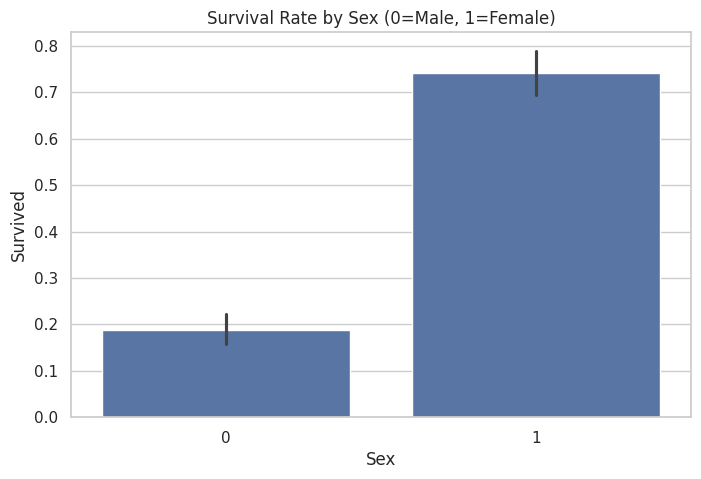

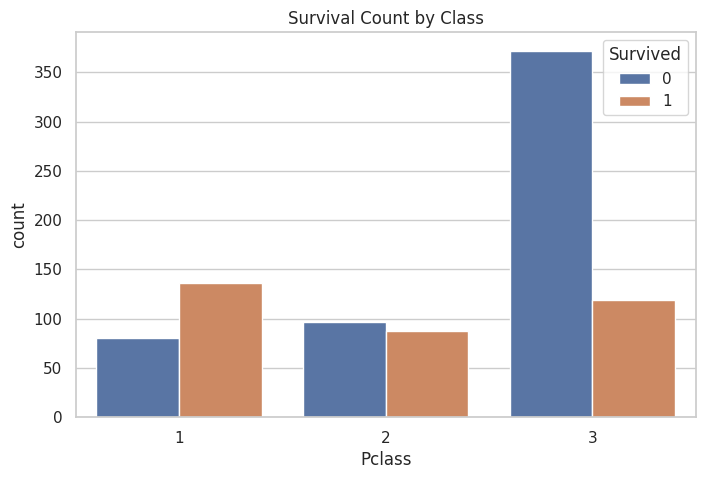

In [23]:
# Set the style
sns.set_theme(style="whitegrid")
# 1. Survival by Sex
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex (0=Male, 1=Female)')
plt.show()
# 2. Survival by Class
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Class')
plt.show()

#FEATURE SCALING

In [25]:
scaler = StandardScaler()

In [26]:
# We scale Age and Fare
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

print("Data is now Scaled and Ready")
df.head()

Data is now Scaled and Ready


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,False,True
1,1,1,1,0.663861,1,0,0.786845,False,False
2,1,3,1,-0.258337,0,0,-0.488854,False,True
3,1,1,1,0.433312,1,0,0.420730,False,True
4,0,3,0,0.433312,0,0,-0.486337,False,True
